🚀 Đang đọc dữ liệu CSV...

✅ Đã lưu ảnh thành công tại: D:\GitHub\RL_Network_Demo\results\training_learning_curve.png


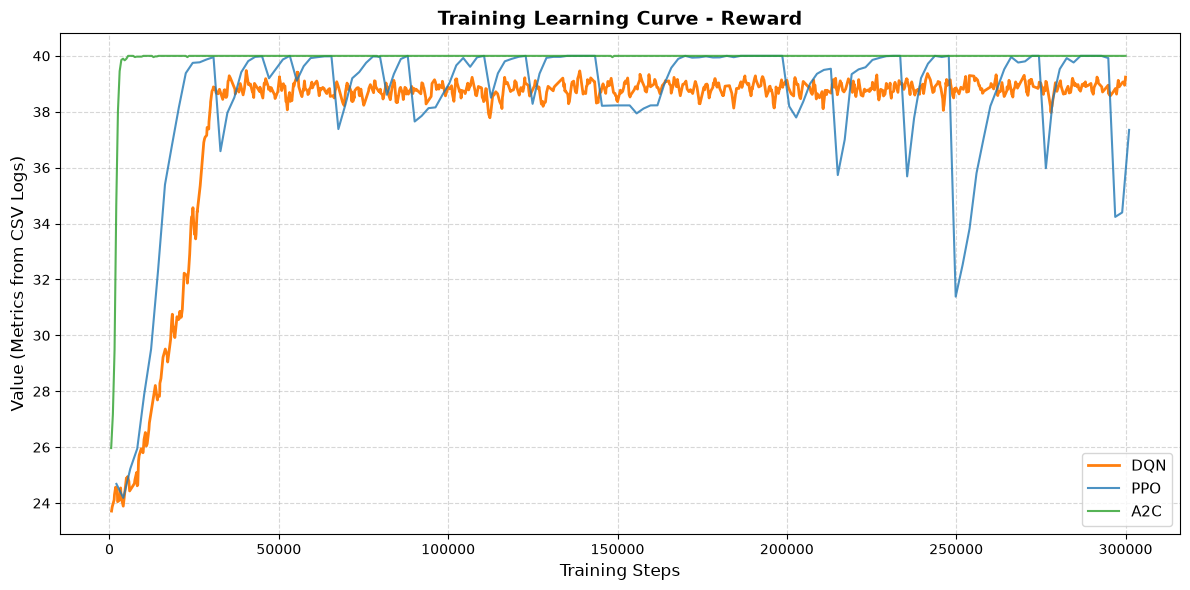

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Định nghĩa thư mục chứa dữ liệu local
data_dir = r"D:\GitHub\RL_Network_Demo\Data"

# 1. Đọc dữ liệu từ VS Code (Local)
print("🚀 Đang đọc dữ liệu CSV...")
df_ppo = pd.read_csv(os.path.join(data_dir, 'PPO_4.csv'))
df_a2c = pd.read_csv(os.path.join(data_dir, 'a2c_A2C_4.csv'))
df_dqn = pd.read_csv(os.path.join(data_dir, 'dqn_DQN_4.csv'))

# 2. Tính toán trung bình trượt (Moving Average) với window=10 để mượt mà nhưng không mất đỉnh/đáy
window_size = 1
df_ppo['smoothed'] = df_ppo['Value'].rolling(window=window_size, min_periods=1).mean()
df_a2c['smoothed'] = df_a2c['Value'].rolling(window=window_size, min_periods=1).mean()
df_dqn['smoothed'] = df_dqn['Value'].rolling(window=window_size, min_periods=1).mean()

# 3. Tạo và vẽ biểu đồ
plt.figure(figsize=(12, 6))

# Vẽ 3 mô hình tương ứng với dữ liệu CSV hiện tại
plt.plot(df_dqn['Step'], df_dqn['smoothed'], label='DQN', color='#ff7f0e', linewidth=2)
plt.plot(df_ppo['Step'], df_ppo['smoothed'], label='PPO', color='#1f77b4', linewidth=1.5, alpha=0.8)
plt.plot(df_a2c['Step'], df_a2c['smoothed'], label='A2C', color='#2ca02c', linewidth=1.5, alpha=0.8)

# 4. Trang trí hệ trục tọa độ
plt.title('Training Learning Curve - Reward', fontsize=14, fontweight='bold')
plt.xlabel('Training Steps', fontsize=12)

# Tự động điều chỉnh tiêu đề trục Y dựa trên bản chất dữ liệu để tránh nhầm lẫn
plt.ylabel('Value (Metrics from CSV Logs)', fontsize=12)

# XÓA HOÀN TOÀN dòng plt.ylim(-210, 5) để hệ thống tự động co giãn theo dữ liệu thực
# Việc này giúp hiển thị rõ ràng đường đi của DQN nằm dưới A2C/PPO nếu đây là đồ thị Episode Length.
plt.autoscale(enable=True, axis='y', tight=False)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best', fontsize=11)

# ==========================================
# 5. LƯU FILE TRÊN LOCAL (VS CODE)
# ==========================================
# Chuyển thư mục lưu ảnh về cùng thư mục dự án trên máy bạn
output_dir = r"D:\GitHub\RL_Network_Demo\results"
os.makedirs(output_dir, exist_ok=True)

save_path = os.path.join(output_dir, 'training_learning_curve.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Đã lưu ảnh thành công tại: {save_path}")

# Hiển thị trên Notebook hoặc cửa sổ đồ họa
plt.tight_layout()
plt.show()